
# Vanilla Policy Gradient (REINFORCE)


As discussed in the [[Policy Optimization (PG)]] the core objective is:

$$
\mathbb{E}\left[\log \pi_\theta(a_t\mid s_t) \cdot G_t\right]
$$
This implementation does not use baseline.

In [ ]:
from typing import Optional, Sequence, Tuple

import gymnasium as gym
import numpy as np
import torch
from torch import Tensor
from torch.distributions import Categorical

from pg_env import (
    EarlyStoppingConfig,
    EnvFn,
    EpisodeBatch,
    MLPPolicy,
    make_cartpole_env,
    plot_training_history,
    run_demo_episode,
    set_seed,
    to_tensor,
    train_on_policy_agent,
)


This is what basically works as the Advantage function.

In [ ]:
def compute_discounted_returns(rewards: Sequence[float], gamma: float) -> Tensor:
    """
    Compute rewards-to-go:
        G_t = r_t + gamma * r_{t+1} + gamma^2 * r_{t+2} + ...

    Returns a 1D float32 tensor of shape [T].
    """
    returns = []
    running_return = 0.0

    for reward in reversed(rewards):
        running_return = reward + gamma * running_return
        returns.append(running_return)

    returns.reverse()
    return torch.tensor(returns, dtype=torch.float32)

This simply normalize the returns. 

In [3]:
def normalized_returns(rewards: Sequence[float], gamma: float) -> Tensor:
    """
    Compute discounted rewards-to-go and normalize them.
    """
    returns = compute_discounted_returns(rewards=rewards, gamma=gamma)

    if returns.numel() > 1:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    return returns


Here we implement the Reinforce Agent. 

In [4]:
class ReinforceAgent:
    """
    Minimal REINFORCE agent for discrete action spaces.

    This class owns:
    - the policy network
    - the optimizer
    - the single-episode REINFORCE update

    It does not own the environment or the training loop.
    """

    def __init__(
        self,
        obs_dim: int,
        act_dim: int,
        hidden_sizes: Sequence[int] = (64, 64),
        learning_rate: float = 1e-2,
        gamma: float = 0.99,
        device: Optional[torch.device] = None,
    ) -> None:
        self.device = device or torch.device("cpu")
        self.gamma = gamma

        self.policy = MLPPolicy(
            obs_dim=obs_dim,
            act_dim=act_dim,
            hidden_sizes=hidden_sizes,
        ).to(self.device)

        self.optimizer = torch.optim.Adam(self.policy.parameters(), lr=learning_rate)

    def distribution(self, obs: np.ndarray) -> Categorical:
        """Build the current policy distribution for one observation."""
        obs_tensor = to_tensor(obs, self.device)
        logits = self.policy(obs_tensor)
        return Categorical(logits=logits)

    def sample_action(self, obs: np.ndarray) -> Tuple[int, Tensor]:
        """
        Sample an action during training and return:
        - the sampled action
        - the log-probability of that exact sampled action
        """
        dist = self.distribution(obs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return int(action.item()), log_prob

    def predict_action(self, obs: np.ndarray) -> int:
        """Greedy action selection used during evaluation or demos."""
        with torch.no_grad():
            obs_tensor = to_tensor(obs, self.device)
            logits = self.policy(obs_tensor)
            action = torch.argmax(logits, dim=-1)
            return int(action.item())

    def update_from_episode(self, episode: EpisodeBatch) -> float:
        """
        Apply one REINFORCE update from a single complete episode.

        Objective:
            maximize sum_t log pi(a_t | s_t) * G_t

        Because PyTorch optimizers do gradient descent, we minimize the negative
        of that objective.
        """
        returns = normalized_returns(episode.rewards, gamma=self.gamma).to(self.device)
        log_probs = torch.cat(episode.log_probs, dim=0)

        loss = -(log_probs * returns).sum()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return float(loss.item())


## Environment-facing helper

The notebook only needs a small builder that inspects the environment and creates a compatible agent.

## Return signal used by this notebook

For this first REINFORCE version, the learning signal is the **normalized discounted return**. Later, we will replace this with a baseline-derived advantage.

In [5]:
def build_reinforce_agent_from_env(
    env_fn: EnvFn,
    hidden_sizes: Sequence[int] = (64, 64),
    learning_rate: float = 1e-2,
    gamma: float = 0.99,
    device: Optional[torch.device] = None,
) -> ReinforceAgent:
    """
    Inspect one environment instance to infer observation and action sizes,
    then construct a compatible REINFORCE agent.
    """
    env = env_fn()

    assert isinstance(env.observation_space, gym.spaces.Box), "Expected Box observation space."
    assert isinstance(env.action_space, gym.spaces.Discrete), "Expected Discrete action space."

    obs_dim = int(np.prod(env.observation_space.shape))
    act_dim = int(env.action_space.n)

    env.close()

    return ReinforceAgent(
        obs_dim=obs_dim,
        act_dim=act_dim,
        hidden_sizes=hidden_sizes,
        learning_rate=learning_rate,
        gamma=gamma,
        device=device,
    )


[episode    1] train_return=  10.00 | loss=  -0.2102 | eval_mean_return=   9.60
[episode   25] train_return=  15.00 | loss=  -0.1303 | eval_mean_return=   9.20
[episode   50] train_return=  59.00 | loss=   0.6655 | eval_mean_return=   9.60
[episode   75] train_return=  14.00 | loss=  -0.5552 | eval_mean_return=   9.10
[episode  100] train_return=  14.00 | loss=   0.3439 | eval_mean_return=   9.50
[episode  125] train_return=  13.00 | loss=  -0.0830 | eval_mean_return=   9.70
[episode  150] train_return=  30.00 | loss=  -0.1414 | eval_mean_return=   9.40
[episode  175] train_return=  18.00 | loss=   0.0254 | eval_mean_return=   9.00
[episode  200] train_return=  13.00 | loss=   0.4136 | eval_mean_return=   9.10
[episode  225] train_return=  22.00 | loss=   0.1684 | eval_mean_return=   9.70
[episode  250] train_return=  15.00 | loss=   0.0238 | eval_mean_return=  26.30
[episode  275] train_return=  15.00 | loss=   0.1419 | eval_mean_return=  28.60
[episode  300] train_return=  36.00 | lo

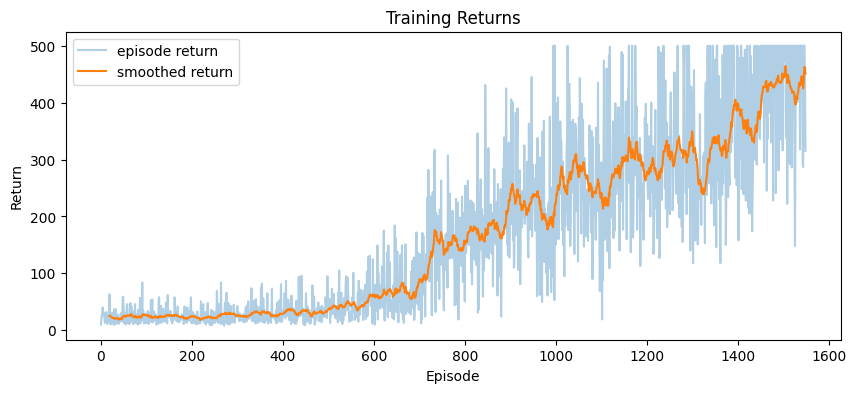

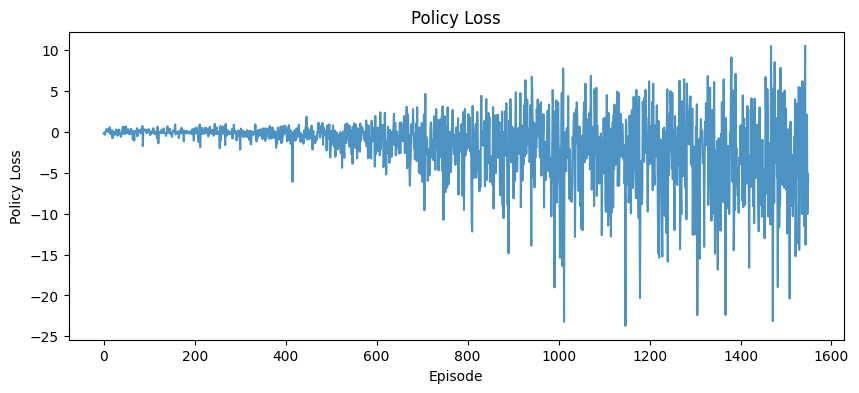

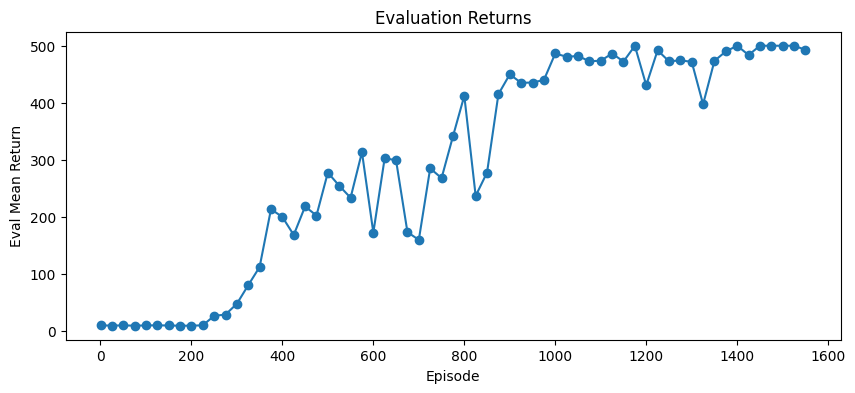

Stopped at iteration 1550: no eval improvement greater than 5.00 for 15 evals


In [6]:
set_seed(42)

env_fn: EnvFn = lambda: make_cartpole_env(render_mode=None)

agent = build_reinforce_agent_from_env(
    env_fn=env_fn,
    hidden_sizes=(32, 32),
    learning_rate=3e-4,
    gamma=0.99,
)

history = train_on_policy_agent(
    env_fn=env_fn,
    agent=agent,
    num_episodes=10_000,
    eval_every=25,
    eval_episodes=10,
    early_stopping=EarlyStoppingConfig(
        patience_evals=15,
        min_delta=5.0,
    ),
    verbose=True,
)

plot_training_history(history)

if history.stopped_early:
    print(f"Stopped at iteration {history.stop_iteration}: {history.stop_reason}")


In [7]:
visual_env: EnvFn = lambda: make_cartpole_env(render_mode="human")

run_demo_episode(visual_env, agent, greedy=True)


/mnt/hd/Repos/ds_be_like/.venv/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Demo return: 500.00


500.0